# Tutorial for Classifier Hyperparameter Optimization (HPO) using Optuna
This notebook leverages the Optuna framework to perform hyperparameter optimization on classification tasks.
Basic concepts of Optuna:
* Study: an optimization based on an objective function
* Trial: a single execution of the objective function
The goal of a study is to find out the optimal set of hyperparameter values through multiple trials. The optuna framework is designed for the automation and the acceleration of the optimization studies.

What are the steps required to provide a good hyperparameter optimization pipeline?
* Cross-validation (LOO or other?)

## Optuna
Basic concepts:
* `Study`: an optimization based on an objective function
* `Trial`: a single execution of the objective function
The goal of a `study` is to find out the optimal set of hyperparameter values through multiple `trials`.

We start with a first simple Optuna example. The goal will be to minimize the (x-2)^2 function.

In [1]:
import os
os.chdir('..')

import optuna
import sklearn
from sklearn import datasets, ensemble
import sklearn.svm

In [2]:
optuna.__version__

'4.1.0'

In [3]:
def objective(trial):
    """
        The function you wan to optimize
    """
    x = trial.suggest_float('x', -10, 10)
    return (x - 2) ** 2

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

study.best_params  # E.g. {'x': 2.002108042}

[I 2025-01-14 10:39:16,531] A new study created in memory with name: no-name-05704584-1043-46d1-91aa-a96f4f9d8411
[I 2025-01-14 10:39:16,533] Trial 0 finished with value: 6.657785589252308 and parameters: {'x': 4.580268511076378}. Best is trial 0 with value: 6.657785589252308.
[I 2025-01-14 10:39:16,533] Trial 1 finished with value: 4.967587453347126 and parameters: {'x': 4.228808527744617}. Best is trial 0 with value: 6.657785589252308.
[I 2025-01-14 10:39:16,535] Trial 2 finished with value: 108.20567840858332 and parameters: {'x': -8.402195845521431}. Best is trial 2 with value: 108.20567840858332.
[I 2025-01-14 10:39:16,535] Trial 3 finished with value: 70.27637892794026 and parameters: {'x': -6.3831007943326235}. Best is trial 2 with value: 108.20567840858332.
[I 2025-01-14 10:39:16,536] Trial 4 finished with value: 143.66864202354287 and parameters: {'x': -9.986185465924631}. Best is trial 4 with value: 143.66864202354287.
[I 2025-01-14 10:39:16,536] Trial 5 finished with value: 

{'x': -9.986185465924631}

## Scikit-learn model HPO
We can go further and define an advanced objective function, which returns the objective function over a scikit-learn model. Note that the objective function receives a `trial` object as parameter. The `trial` has several methods for sampling hyperparameters. The idea is to first define the possible values of these hyperparameters then use them to define the model, as with any other variables. The objective function typically contains these different steps:
* Prepare and load the data
* Define the hyperparameters to tune using the `trial`object.
* Instantiate the model
* Train the model
* Evaluate the model and return the evaluation function

**Saving studies:**  We store Optuna studies as sqlite3 files. Multiple studies can be stored in the same file as long as they have a different name.  
**Optuna Dashboard:** It's then possible to open studies in multiple ways. The prefered option is the command line interface, which instanciate a web server, allowing analysis in a web browser.This provides more details than opening it in the VSCode extension. 
To run the web server for Optuna Dashboard, run: 
> optuna-dashboard sqlite:///generated/hpo_example.sqlite3  


The files are updated dynamically, so new studies can be analyzed in real time.

**Sampler:** 
It's possible to define different samplers based on the optimization required, but the authors suggest using the AutoSampler (https://hub.optuna.org/samplers/auto_sampler/). If you need to choose, use this cheat sheet or the official documentation (image from https://www.youtube.com/watch?v=P6NwZVl8ttc&t=13s):  
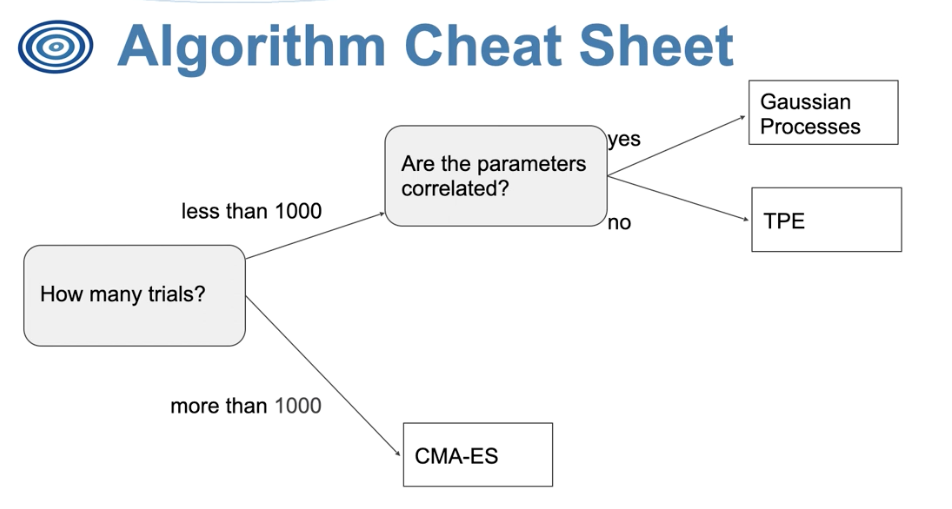  
The default sampler is TPE (Bayesian optimization based on kernel fitting), which should work well in most cases. The full samplers list can be found in the API documenation: https://optuna.readthedocs.io/en/stable/reference/samplers/index.html.

**Reproducible sampling caveat:** 
* When optimizing a study in distributed or parallel mode, there is inherent non-determinism. Thus it is very difficult to reproduce the same results in such condition. We recommend executing optimization of a study sequentially if you would like to reproduce the result.
* If your objective function behaves in a non-deterministic way (i.e., it does not return the same value even if the same parameters were suggested), you cannot reproduce an optimization. To deal with this problem, please set an option (e.g., random seed) to make the behavior deterministic if your optimization target (e.g., an ML library) provides it.

In [4]:
i=6

In [5]:
def objective(trial):
    # prepare data
    iris = sklearn.datasets.load_iris()

    # define the hyperparameters to tune
    n_estimators = trial.suggest_int("n_estimators", 2, 20)
    max_depth = trial.suggest_int("max_depth", 1, 32, log=True)

    # define the model
    clf = sklearn.ensemble.RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth)

    # train and evaluate the model (can of course be done in two steps)
    return sklearn.model_selection.cross_val_score(
        clf, iris.data, iris.target, n_jobs=-1, cv=3
    ).mean()

i = i+1

sampler = optuna.samplers.TPESampler(seed=10)  # Make the sampler behave in a deterministic way.
study = optuna.create_study(
    sampler=sampler,
    direction="maximize",
    storage="sqlite:///generated/hpo_example.sqlite3",  # Required for optuna dashboard
    study_name=f"{i} trial")
study.optimize(objective, n_trials=10)

trial = study.best_trial

print("Accuracy: {}".format(trial.value))
print("Best hyperparameters: {}".format(trial.params))

[I 2025-01-14 10:39:18,065] A new study created in RDB with name: 7 trial
[I 2025-01-14 10:39:22,095] Trial 0 finished with value: 0.86 and parameters: {'n_estimators': 16, 'max_depth': 1}. Best is trial 0 with value: 0.86.
[I 2025-01-14 10:39:22,877] Trial 1 finished with value: 0.9666666666666667 and parameters: {'n_estimators': 14, 'max_depth': 11}. Best is trial 1 with value: 0.9666666666666667.
[I 2025-01-14 10:39:22,912] Trial 2 finished with value: 0.8266666666666667 and parameters: {'n_estimators': 11, 'max_depth': 1}. Best is trial 1 with value: 0.9666666666666667.
[I 2025-01-14 10:39:23,682] Trial 3 finished with value: 0.9666666666666667 and parameters: {'n_estimators': 5, 'max_depth': 12}. Best is trial 1 with value: 0.9666666666666667.
[I 2025-01-14 10:39:23,715] Trial 4 finished with value: 0.8666666666666667 and parameters: {'n_estimators': 5, 'max_depth': 1}. Best is trial 1 with value: 0.9666666666666667.
[I 2025-01-14 10:39:24,490] Trial 5 finished with value: 0.94666

Accuracy: 0.9666666666666667
Best hyperparameters: {'n_estimators': 14, 'max_depth': 11}


In [6]:
study.trials_dataframe()

,number,value,datetime_start,datetime_complete,duration,params_max_depth,params_n_estimators,state
0,0,0.860000,2025-01-14 10:39:18.072266,2025-01-14 10:39:22.086328,0 days 00:00:04.014062,1,16,COMPLETE
1,1,0.966667,2025-01-14 10:39:22.099057,2025-01-14 10:39:22.869421,0 days 00:00:00.770364,11,14,COMPLETE
2,2,0.826667,2025-01-14 10:39:22.882985,2025-01-14 10:39:22.906796,0 days 00:00:00.023811,1,11,COMPLETE
3,3,0.966667,2025-01-14 10:39:22.915166,2025-01-14 10:39:23.675902,0 days 00:00:00.760736,12,5,COMPLETE
4,4,0.866667,2025-01-14 10:39:23.685784,2025-01-14 10:39:23.711163,0 days 00:00:00.025379,1,5,COMPLETE
5,5,0.946667,2025-01-14 10:39:23.718944,2025-01-14 10:39:24.484618,0 days 00:00:00.765674,27,15,COMPLETE
6,6,0.933333,2025-01-14 10:39:24.494147,2025-01-14 10:39:24.521206,0 days 00:00:00.027059,4,2,COMPLETE
7,7,0.960000,2025-01-14 10:39:24.529353,2025-01-14 10:39:24.566903,0 days 00:00:00.037550,6,17,COMPLETE
8,8,0.940000,2025-01-14 10:39:24.575746,2025-01-14 10:39:24.613592,0 days 00:00:00.037846,2,15,COMPLETE
9,9,0.960000,2025-01-14 10:39:24.621389,2025-01-14 10:39:24.658238,0 days 00:00:00.036849,10,19,COMPLETE


Note that it is also possible to add if/else clauses over the hyperparameters in the objective function. Optuna will automatically take care of the logic behind it (i.e. defining hyperparameters related to each if/else clauses). This way allows you to optimize and compare multiple models (or pipelines).  
For instance, you might want to optimize the C parameter of SVM but the max_depth parameter of RandomForest. With optuna, you can simply use the `trial` object to log the hyperparameters of each object.

In [ ]:
def objective(trial):
    iris = sklearn.datasets.load_iris()

    classifier = trial.suggest_categorical("classifier", ["RandomForest", "SVC"])

    if classifier == "RandomForest":
        n_estimators = trial.suggest_int("n_estimators", 2, 20)
        max_depth = int(trial.suggest_float("max_depth", 1, 32, log=True))

        clf = sklearn.ensemble.RandomForestClassifier(
            n_estimators=n_estimators, max_depth=max_depth
        )
    else:
        c = trial.suggest_float("svc_c", 1e-10, 1e10, log=True)

        clf = sklearn.svm.SVC(C=c, gamma="auto")

    return sklearn.model_selection.cross_val_score(
        clf, iris.data, iris.target, n_jobs=-1, cv=3
    ).mean()


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

trial = study.best_trial

print("Accuracy: {}".format(trial.value))
print("Best hyperparameters: {}".format(trial.params))

## Results visualization
Optuna proposes different visualization to analyze the study (i.e. the different trials results). Some of them are presented below. Also, note that the **Optuna Dashboard** provides a web dynamic and interactive interface to analyze studies.

In [ ]:
optuna.visualization.plot_optimization_history(study)

In [ ]:
optuna.visualization.plot_slice(study)

In [ ]:
optuna.visualization.plot_contour(study, params=["svc_c"]) # rf_max_depth